# Reproducing Figures 1 and 3 of *Revisiting Multimodal Positional Encoding in Vision–Language Models*

Paper: [arXiv:2510.23095](https://arxiv.org/abs/2510.23095) (ICLR 2026).

The paper decomposes multimodal RoPE into **position design** (Figure 1) and **frequency allocation**
(Figure 3, the README's second image; Figure 2 of the arXiv v3 is a measured attention map that needs a
trained model). Sections 1–3 reproduce Figure 1, section 4 adds an interactive version of it, and
section 5 reproduces Figure 3.

Figure 1 compares the position design of six multimodal RoPE families on one interleaved
sequence

`<system prompt>, <video 1>, <text>, <image 1>, <text>, <image 2>, <text>, <image 3>, <text>, <generated text>`

Every token is drawn at its 3D position id $(t, h, w)$: text tokens in blue, visual tokens in orange,
generated text in green, and a thin red line links the last token of each block to the first token of
the next one.

Instead of re-deriving the layouts, this notebook calls the repository's own position-design functions
(`multimodal_ropes/pos_design/*.py`, the code that `test.py` monkey-patches into Qwen3-VL's
`get_rope_index`) on a synthetic token sequence, so the plotted coordinates are exactly what the language
model would receive.

Requirements: `torch`, `numpy`, `matplotlib`, `plotly` (installed automatically if missing). `transformers` is
**not** needed. The first cell clones the repository when the notebook is opened outside of it, e.g. in
Google Colab, so the notebook runs on its own.

In [1]:
import importlib
import subprocess
import sys
import types
from pathlib import Path
from types import SimpleNamespace

# --- self-sufficient setup: find the repository, or clone it (e.g. Google Colab) ------------
REPO_URL = "https://github.com/YongchengYAO/Multimodal-RoPEs.git"
REPO_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "multimodal_ropes").is_dir()), None)
if REPO_ROOT is None:
    REPO_ROOT = Path.cwd() / "Multimodal-RoPEs"
    if not REPO_ROOT.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_ROOT)], check=True)
(REPO_ROOT / "notebooks").mkdir(exist_ok=True)       # where the figures are written
missing = [m for m in ("torch", "numpy", "matplotlib", "plotly") if importlib.util.find_spec(m) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", *missing], check=True)
    importlib.invalidate_caches()

import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.offsetbox import AnnotationBbox, HPacker, TextArea, VPacker
from matplotlib.patches import Ellipse, FancyBboxPatch, Rectangle
from mpl_toolkits.mplot3d import proj3d

# `multimodal_ropes/__init__.py` imports the frequency-allocation modules, which require
# transformers 5.3.0. Position design only needs torch, so register the package path by hand
# and import the two sub-packages we need without executing `__init__.py`.
pkg = types.ModuleType("multimodal_ropes")
pkg.__path__ = [str(REPO_ROOT / "multimodal_ropes")]
sys.modules.setdefault("multimodal_ropes", pkg)

from multimodal_ropes.configs import (
    CircleRopeConfig, MRopeConfig, MRopeInterleaveConfig, OmniRopeConfig,
    VanillaRopeConfig, VideoRopeConfig,
)
from multimodal_ropes.pos_design import (
    get_circlerope_index, get_mrope_index, get_mrope_interleave_index,
    get_omnirope_index, get_vanilla_rope_index, get_videorope_index,
)

print("repo:", REPO_ROOT)

repo: /mnt/vincent-pvc-rwm/Github/Multimodal-RoPEs


## 1. The interleaved multimodal sequence

The paper does not list the exact token counts behind Figure 1, so the numbers below are read off the
plot: a 2-token system prompt, a 10-frame video whose frames are 4×4 LLM tokens, three images of 6×6,
10×10 and 14×14 tokens separated by 8 text tokens, a short 3-token instruction, and 8 generated tokens.
Grids are given directly in LLM tokens (i.e. *after* Qwen's 2×2 patch merge), which is why the stub
config below uses `spatial_merge_size=1`.

Every `get_*_index` function locates visual blocks the way Qwen does: a `<vision_start>` token
followed by a run of image/video tokens, closed by `<vision_end>`. The token ids themselves are
arbitrary, they only have to match the stub config.

**Video handling.** The repository's `video_grid_thw` code path implements Qwen3-VL's layout, in which
every frame becomes its own `<vision_start> … <vision_end>` block separated by timestamp text (see the
`repeat_interleave` at the top of each function). Figure 1 depicts the Qwen2-VL layout instead: one
block with `t = 10`, which is exactly the image code path with a temporal extent. We therefore pass the
video through `image_grid_thw` with `t = 10`.

In [2]:
TEXT, VISION_START, VISION_END, IMAGE, VIDEO = 1, 2, 3, 4, 5   # arbitrary token ids

# (name, role, n_tokens) for text, (name, role, (t, h, w)) for visual blocks
SEQUENCE = [
    ("system prompt", "text", 2),
    ("video 1", "visual", (10, 4, 4)),
    ("text 1", "text", 8),
    ("image 1", "visual", (1, 6, 6)),
    ("text 2", "text", 8),
    ("image 2", "visual", (1, 10, 10)),
    ("text 3", "text", 8),
    ("image 3", "visual", (1, 14, 14)),
    ("text 4", "text", 3),
    ("generated text", "generated", 8),
]

ids, roles, blocks, grids = [], [], [], []
for b, (name, role, spec) in enumerate(SEQUENCE):
    if role == "visual":
        t, h, w = spec
        ids += [VISION_START] + [IMAGE] * (t * h * w) + [VISION_END]
        roles += ["text"] + ["visual"] * (t * h * w) + ["text"]   # the wrapper tokens are text
        grids.append(spec)
    else:
        ids += [TEXT] * spec
        roles += [role] * spec
    blocks += [b] * (len(ids) - len(blocks))

input_ids = torch.tensor([ids])          # [batch=1, seq_len]
grid_thw = torch.tensor(grids)           # [n_visual_blocks, 3]
roles = np.array(roles)
blocks = np.array(blocks)
BLOCK_ID = {name: b for b, (name, _, _) in enumerate(SEQUENCE)}

def tokens(name, visual_only=False):
    idx = np.where(blocks == BLOCK_ID[name])[0]
    return idx[roles[idx] == "visual"] if visual_only else idx

# The repo functions are methods of Qwen3VLModel and only read these config fields from `self`.
model_stub = SimpleNamespace(config=SimpleNamespace(
    vision_config=SimpleNamespace(spatial_merge_size=1),
    image_token_id=IMAGE, video_token_id=VIDEO, vision_start_token_id=VISION_START,
))

print(f"{input_ids.shape[1]} tokens, visual blocks (t, h, w): {grid_thw.tolist()}")

537 tokens, visual blocks (t, h, w): [[10, 4, 4], [1, 6, 6], [1, 10, 10], [1, 14, 14]]


## 2. Position design of each variant

| Panel | Repo function | Configuration | Remarks |
|---|---|---|---|
| (a) Vanilla RoPE / V2PE | `get_vanilla_rope_index` | – | V2PE only shrinks the stride of visual tokens; the layout stays 1D. |
| (b) MRoPE | `get_mrope_index` | `temporal_stride=1` | Qwen2-VL: visual tokens get $(t,h,w)$ offset after the preceding text. |
| (c) VideoRoPE / HoPE | `get_videorope_index` | `temporal_stride=2` | Diagonal layout: $h, w$ are centred on the frame and added to $t$. HoPE reuses it. |
| (d) CircleRoPE | `get_circlerope_index` | `radius="auto"`, `move_to_origin`, `move_to_positive`, `alpha=0` | Each image is mapped onto a circle orthogonal to the text axis $(1,1,1)$. |
| (e) IL-RoPE / Omni-RoPE | `get_omnirope_index` | `text_spatial_zero=True` | Visual blocks use `(shift, row, col)`; see the note below. |
| (f) MHRoPE / MRoPE-I | `get_mrope_interleave_index` | `spatial_reset=True` | MHRoPE shares this position design and differs only in frequency allocation. |

Two panel-specific choices:

* **(d)** The repository stacks video frames along the text axis with `temporal_stride`. The paper draws
  the video as one "squeezed" blob, so we use a near-zero stride (the config rejects `0`) and the
  automatic radius, which grows with the image size like the bars in the paper.
* **(e)** The repository keeps text tokens on the diagonal $(p,p,p)$. Figure 1(e) and Table 1 of the
  paper instead put IL-RoPE/Omni-RoPE text at $(t,0,0)$, which is what makes them "not compatible with
  text-only RoPE". We zero the spatial rows of text tokens after the call to match the paper.

In [3]:
def positions(get_index, config, text_spatial_zero=False):
    pos, _rope_deltas = get_index(
        model_stub, input_ids=input_ids, image_grid_thw=grid_thw.clone(), extra_config=config
    )
    pos = pos[:, 0].to(torch.float64).numpy()   # [3, seq_len], rows = (t, h, w)
    if text_spatial_zero:
        pos[1:, roles != "visual"] = 0.0
    return pos

PANELS = [
    ("(a) Vanilla RoPE / V2PE",
     positions(get_vanilla_rope_index, VanillaRopeConfig(dim=128))),
    ("(b) MRoPE",
     positions(get_mrope_index, MRopeConfig(dim=128, temporal_stride=1))),
    ("(c) VideoRoPE / HoPE",
     positions(get_videorope_index, VideoRopeConfig(dim=128, temporal_stride=2))),
    ("(d) CircleRoPE",
     positions(get_circlerope_index, CircleRopeConfig(
         dim=128, radius="auto", alpha=0.0, move_to_origin=True, move_to_positive=True,
         temporal_stride=0.1))),
    ("(e) IL-RoPE / Omni-RoPE",
     positions(get_omnirope_index, OmniRopeConfig(dim=128), text_spatial_zero=True)),
    ("(f) MHRoPE / MRoPE-I",
     positions(get_mrope_interleave_index, MRopeInterleaveConfig(dim=128, spatial_reset=True))),
]

for caption, pos in PANELS:
    print(f"{caption:26s} max (t, h, w) = {np.round(pos.max(axis=1), 1)}")

(a) Vanilla RoPE / V2PE    max (t, h, w) = [536. 536. 536.]
(b) MRoPE                  max (t, h, w) = [84. 84. 84.]
(c) VideoRoPE / HoPE       max (t, h, w) = [66. 66. 66.]
(d) CircleRoPE             max (t, h, w) = [77.4 77.4 77.4]
(e) IL-RoPE / Omni-RoPE    max (t, h, w) = [84. 13. 13.]
(f) MHRoPE / MRoPE-I       max (t, h, w) = [84. 84. 84.]


## 3. Drawing the figure

Each panel is a 3D scatter with $W$ on the x-axis, $H$ on the y-axis and $T$ on the z-axis, equal limits
on the three axes (otherwise matplotlib would stretch the small spatial range of panel (e) over the whole
box), and the default matplotlib view (`elev=30, azim=-60`), which is what the paper uses.

The red call-outs of the paper are attached to data, not to fixed pixel positions: `to_frac` projects a
3D point with `proj3d.proj_transform` and converts it to axes-fraction coordinates, so boxes and arrows
follow the tokens if you change the sequence above. Because the projection depends on the final layout,
the figure is drawn once (`fig.canvas.draw()`) before the annotations are added.

saved /mnt/vincent-pvc-rwm/Github/Multimodal-RoPEs/notebooks/figure1_position_design.png


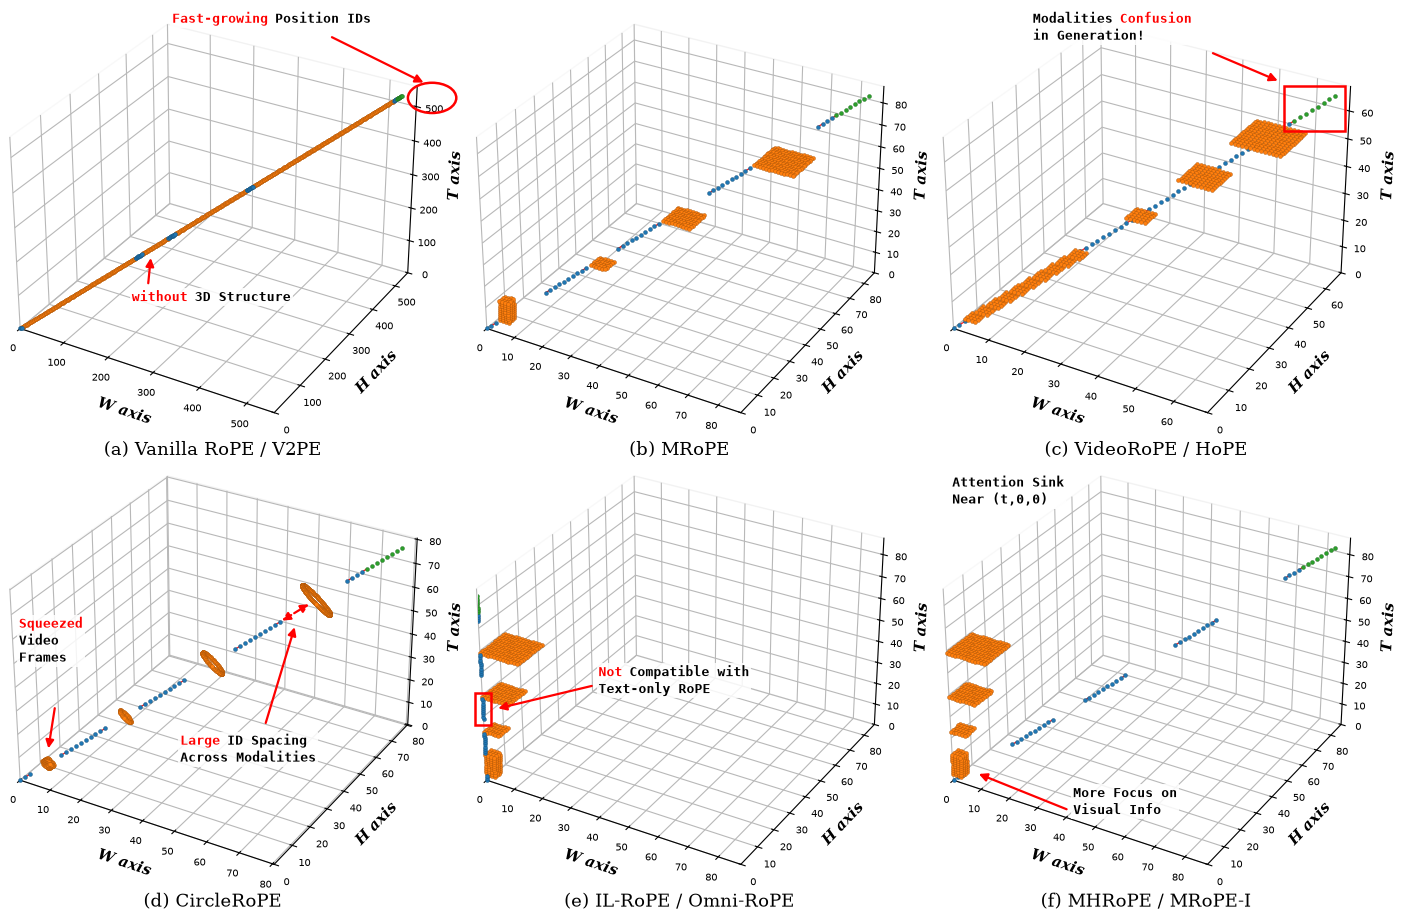

In [4]:
mpl.rcParams.update({"grid.color": "0.72", "grid.linewidth": 0.8, "font.size": 9})
COLORS = {"text": "C0", "visual": "C1", "generated": "C2"}
RED, BLACK = "red", "black"


def draw_panel(ax, pos, caption):
    t, h, w = pos
    for b in range(blocks.max()):   # red link: last token of a block -> first token of the next
        i, j = np.where(blocks == b)[0][-1], np.where(blocks == b + 1)[0][0]
        ax.plot([w[i], w[j]], [h[i], h[j]], [t[i], t[j]], color=RED, lw=0.9, alpha=0.9)
    for role in ("visual", "text", "generated"):
        m = roles == role
        edge = tuple(0.65 * c for c in to_rgb(COLORS[role]))
        ax.scatter(w[m], h[m], t[m], s=8, c=COLORS[role], depthshade=False,
                   edgecolors=[edge], linewidths=0.3)
    lo, hi = min(pos.min(), 0.0), pos.max() * 1.04
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_zlim(lo, hi)
    ax.view_init(elev=30, azim=-60)
    ax.set_box_aspect((4, 4, 3), zoom=1.12)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
    lab = dict(fontstyle="italic", fontweight="bold", family="serif", fontsize=11)
    ax.set_xlabel("W axis", labelpad=-2, **lab)
    ax.set_ylabel("H axis", labelpad=-2, **lab)
    ax.set_zlabel("T axis", labelpad=-4, **lab)
    ax.tick_params(labelsize=7.5, pad=-1)
    ax.set_title(caption, y=-0.13, fontsize=13, family="serif")


# ---- annotation helpers: 3D data -> axes-fraction coordinates -----------------------------
def to_frac(ax, t, h, w):
    x2, y2, _ = proj3d.proj_transform(w, h, t, ax.get_proj())
    return ax.transAxes.inverted().transform(ax.transData.transform((x2, y2)))

def centroid(ax, pos, idx):
    return to_frac(ax, *pos[:, idx].mean(axis=1))

def bbox(ax, pos, idx, pad=0.02):
    pts = np.array([to_frac(ax, *p) for p in pos[:, idx].T])
    (x0, y0), (x1, y1) = pts.min(0) - pad, pts.max(0) + pad
    return x0, y0, x1 - x0, y1 - y0

def label(ax, xy, lines, size=9.5):
    # `lines` is a list of lines; each line is a list of (text, color) pieces
    rows = [HPacker(children=[TextArea(s, textprops=dict(color=c, family="monospace",
                                                          weight="bold", size=size))
                              for s, c in line], pad=0, sep=5) for line in lines]
    box = VPacker(children=rows, pad=0, sep=2, align="left")
    ax.add_artist(AnnotationBbox(box, xy, xycoords=ax.transAxes, box_alignment=(0, 1), pad=0.15,
                                 bboxprops=dict(fc="white", ec="none", alpha=0.85)))

def arrow(ax, tail, head, **kw):
    style = dict(arrowstyle="-|>", color=RED, lw=1.6, mutation_scale=12)
    style.update(kw)
    ax.annotate("", xy=head, xytext=tail, xycoords="axes fraction", textcoords="axes fraction",
                arrowprops=style)

def frame(fig, ax, patch_cls, *args, **kw):
    # 2D patches must live on the figure: Axes3D tries to depth-sort every patch it owns
    fig.add_artist(patch_cls(*args, transform=ax.transAxes, fill=False, ec=RED, lw=1.8, **kw))


def annotate(fig, axes, panels):
    (a, b, c, d, e, f), pos = axes, [p for _, p in panels]
    # (a) 1D ids grow with the sequence length and carry no 3D structure
    ex, ey = to_frac(a, *pos[0][:, -1])
    frame(fig, a, Ellipse, (ex + 0.075, ey - 0.005), 0.12, 0.075)
    label(a, (0.40, 1.0), [[("Fast-growing", RED), ("Position IDs", BLACK)]])
    arrow(a, (0.79, 0.94), (ex + 0.06, ey + 0.03))
    mx, my = to_frac(a, *pos[0][:, len(ids) // 3])
    label(a, (0.30, 0.31), [[("without", RED), ("3D Structure", BLACK)]])
    arrow(a, (0.34, 0.32), (mx + 0.01, my - 0.01))
    # (c) generated text lands inside the spatial extent of the last image
    x0, y0, bw, bh = bbox(c, pos[2], tokens("generated text"), pad=0.025)
    frame(fig, c, Rectangle, (x0, y0), bw, bh)
    label(c, (0.22, 1.0), [[("Modalities", BLACK), ("Confusion", RED)], [("in Generation!", BLACK)]])
    arrow(c, (0.66, 0.90), (x0 - 0.01, y0 + bh + 0.01))
    # (d) video frames collapse onto one ring; images sit far from the neighbouring text
    vx, vy = centroid(d, pos[3], tokens("video 1", True))
    label(d, (0.02, 0.62), [[("Squeezed", RED)], [("Video", BLACK)], [("Frames", BLACK)]])
    arrow(d, (0.11, 0.40), (vx, vy + 0.03))
    ix, iy = centroid(d, pos[3], tokens("image 3", True))
    tx, ty = to_frac(d, *pos[3][:, tokens("text 3")[-1]])
    arrow(d, (tx, ty), (ix, iy), arrowstyle="<|-|>", linestyle="--", shrinkA=6, shrinkB=6)
    label(d, (0.42, 0.33), [[("Large", RED), ("ID Spacing", BLACK)], [("Across Modalities", BLACK)]])
    arrow(d, (0.63, 0.35), ((tx + ix) / 2, (ty + iy) / 2 - 0.03))
    # (e) text leaves the diagonal, so text-only inputs no longer see vanilla RoPE
    x0, y0, bw, bh = bbox(e, pos[4], tokens("text 2"), pad=0.02)
    frame(fig, e, Rectangle, (x0, y0), bw, bh)
    label(e, (0.30, 0.50), [[("Not", RED), ("Compatible with", BLACK)], [("Text-only RoPE", BLACK)]])
    arrow(e, (0.29, 0.45), (x0 + bw + 0.01, y0 + bh / 2))
    # (f) spatial reset gathers visual tokens near (t, 0, 0)
    label(f, (0.02, 0.97), [[("Attention Sink", BLACK)], [("Near (t,0,0)", BLACK)]])
    fx, fy = centroid(f, pos[5], tokens("video 1", True)[:16])
    label(f, (0.32, 0.20), [[("More Focus on", BLACK)], [("Visual Info", BLACK)]])
    arrow(f, (0.31, 0.14), (fx + 0.04, fy))


fig = plt.figure(figsize=(14, 9))
axes = [fig.add_subplot(2, 3, k + 1, projection="3d") for k in range(6)]
for ax, (caption, pos) in zip(axes, PANELS):
    draw_panel(ax, pos, caption)
fig.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.05, wspace=0.0, hspace=0.12)
fig.canvas.draw()                 # finalise the layout before projecting 3D points
annotate(fig, axes, PANELS)

OUT = REPO_ROOT / "notebooks" / "figure1_position_design.png"
fig.savefig(OUT, dpi=200, bbox_inches="tight")
print("saved", OUT)
plt.show()

## 4. Interactive Figure 1

The matplotlib panels above are static images. This cell rebuilds them with Plotly: drag inside a panel to rotate
it, scroll to zoom, hover over a token to read its block, role and $(t, h, w)$, and click a legend entry to hide
that role in all six panels at once. Each camera starts at matplotlib's default view (elevation 30°, azimuth
−60°); Plotly cannot link the cameras of several 3D scenes, so the panels rotate independently.

The figure is also written to `figure1_position_design_interactive.html`, a standalone page that loads
plotly.js from its CDN.

In [5]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

PLOTLY_COLORS = {"text": "#1f77b4", "visual": "#ff7f0e", "generated": "#2ca02c"}
MARKER_SIZE = {"text": 3.2, "visual": 2.6, "generated": 3.2}
block_names = np.array([SEQUENCE[b][0] for b in blocks])
# matplotlib's default view (elev=30°, azim=-60°) as a Plotly camera position
CAMERA = dict(eye=dict(x=0.9, y=-1.6, z=1.05))


def panel_traces(pos, show_legend):
    t, h, w = pos
    hover = [f"{block_names[i]} · {roles[i]}<br>t={t[i]:g}, h={h[i]:g}, w={w[i]:g}" for i in range(len(roles))]
    lx, ly, lz = [], [], []
    for b in range(blocks.max()):        # red links between consecutive blocks (None breaks the line)
        i, j = np.where(blocks == b)[0][-1], np.where(blocks == b + 1)[0][0]
        lx += [w[i], w[j], None]; ly += [h[i], h[j], None]; lz += [t[i], t[j], None]
    traces = [go.Scatter3d(x=lx, y=ly, z=lz, mode="lines", line=dict(color="red", width=2),
                           hoverinfo="skip", showlegend=False)]
    for role in ("visual", "text", "generated"):
        m = roles == role
        traces.append(go.Scatter3d(
            x=w[m], y=h[m], z=t[m], mode="markers", name=role, legendgroup=role, showlegend=show_legend,
            marker=dict(size=MARKER_SIZE[role], color=PLOTLY_COLORS[role]),
            hovertext=[s for s, keep in zip(hover, m) if keep], hoverinfo="text"))
    return traces


fig_i = make_subplots(rows=2, cols=3, specs=[[{"type": "scene"}] * 3] * 2,
                      subplot_titles=[caption for caption, _ in PANELS],
                      horizontal_spacing=0.01, vertical_spacing=0.06)
for k, (caption, pos) in enumerate(PANELS):
    row, col = divmod(k, 3)
    for trace in panel_traces(pos, show_legend=(k == 0)):
        fig_i.add_trace(trace, row=row + 1, col=col + 1)
    lo, hi = min(pos.min(), 0.0), pos.max() * 1.04
    axis = lambda title: dict(title=title, range=[lo, hi], showbackground=False, gridcolor="#cccccc")
    fig_i.update_scenes(dict(xaxis=axis("W axis"), yaxis=axis("H axis"), zaxis=axis("T axis"),
                             aspectmode="manual", aspectratio=dict(x=1, y=1, z=0.75), camera=CAMERA),
                        row=row + 1, col=col + 1)
fig_i.update_layout(height=820, width=1350, margin=dict(l=0, r=0, t=40, b=0),
                    legend=dict(orientation="h", x=0.5, xanchor="center", y=1.03, itemsizing="constant"))

OUT_HTML = REPO_ROOT / "notebooks" / "figure1_position_design_interactive.html"
fig_i.write_html(OUT_HTML, include_plotlyjs="cdn")
print("saved", OUT_HTML)
fig_i.show()

saved /mnt/vincent-pvc-rwm/Github/Multimodal-RoPEs/notebooks/figure1_position_design_interactive.html


## 5. Figure 3: frequency allocation

Rotary pair $i$ of a head rotates with frequency $\theta_i = \text{base}^{-2i/d}$, so pairs run from high
frequency (left) to low frequency (right); the fading colour in the paper's schematic encodes this decay.
The variants differ only in *which position axis* ($t$, $h$ or $w$) drives each pair, and in the repo that
rule is the `apply_transformation` method of each class in `multimodal_ropes/freq_allocation/`:

| Row | Repo class | Rule |
|---|---|---|
| Vanilla RoPE / V2PE / VRoPE | `RopeEmbedding` | `forward` uses `position_ids[0]` only: every pair is temporal. |
| MRoPE / CircleRoPE / OmniRoPE | `MRopeEmbedding` | chunked: `mrope_section` contiguous blocks for $t$, $h$, $w$. |
| VideoRoPE / HoPE | `VideoRopeEmbedding` | $h$/$w$ alternate over the high-frequency pairs, $t$ keeps the low-frequency tail (HoPE additionally zeroes $t$, i.e. NoPE). |
| IL-RoPE | `MRopeInterleaveEmbedding` | $t,h,w$ round-robin until the spatial budget is spent, then $t$. |
| MRoPE-I | `MRopeInterleaveEmbedding` | same rule with a spatial budget that covers (almost) the whole spectrum. |
| MHRoPE | `MHRopeEmbedding` | `mrope_section=[2, 3, 3]` counts **KV heads**: 2 heads rotate with $t$, 3 with $h$, 3 with $w$, each over the full spectrum. |

These methods are pure torch and do not touch `self` (MHRoPE reads `self.extra_config.num_key_value_heads`),
so we call them unbound on a "tagged" frequency tensor whose three axis rows hold the constants 1, 2, 3 and read
the axis of every pair off the output. Only the `transformers.modeling_rope_utils` import at the top of the
modules needs a two-name stub when transformers is not installed.

The paper draws 19 pairs instead of the 64 of a 128-dim head; the sections below are the paper's proportions:
`[5, 7, 7]` stands for Qwen2-VL's `[16, 24, 24]`, `[7, 6, 6]` for Qwen3-VL's `[24, 20, 20]`, and IL-RoPE's
`[11, 4, 4]` follows the drawing (the repo's IL-RoPE default equals MRoPE-I's, which would make the two rows
identical).

In [6]:
try:
    from transformers.modeling_rope_utils import ROPE_INIT_FUNCTIONS, dynamic_rope_update  # noqa: F401
except ImportError:
    # transformers missing (or too old): the allocation code only needs these two names.
    _stub = types.ModuleType("transformers.modeling_rope_utils")
    _stub.dynamic_rope_update = lambda fn: fn
    _stub.ROPE_INIT_FUNCTIONS = {}
    sys.modules.setdefault("transformers", types.ModuleType("transformers"))
    sys.modules["transformers.modeling_rope_utils"] = _stub

from multimodal_ropes.freq_allocation import (
    MHRopeEmbedding, MRopeEmbedding, MRopeInterleaveEmbedding, VideoRopeEmbedding,
)

N_PAIRS = 19      # width of the paper's schematic (a 128-dim head has 64 pairs)
T, H, W = 1, 2, 3


def channel_axes(embedding_cls, mrope_section, n_pairs=N_PAIRS, **stub_attrs):
    # tagged[axis] == axis + 1 for every pair; apply_transformation picks one axis per pair
    tagged = torch.arange(1, 4, dtype=torch.float).view(3, 1, 1, 1).expand(3, 1, 1, n_pairs).clone()
    out = embedding_cls.apply_transformation(SimpleNamespace(**stub_attrs), tagged, mrope_section)
    return out.reshape(-1, n_pairs).long().numpy()      # [rows, n_pairs]; MHRoPE gives one row per KV head


ROWS = [
    ("Vanilla RoPE / V2PE / VRoPE", np.full((1, N_PAIRS), T)),
    ("MRoPE / CircleRoPE / OmniRoPE", channel_axes(MRopeEmbedding, [5, 7, 7])),
    ("VideoRoPE / HoPE", channel_axes(VideoRopeEmbedding, [5, 7, 7])),
    ("IL-RoPE", channel_axes(MRopeInterleaveEmbedding, [11, 4, 4])),
    ("MRoPE-I", channel_axes(MRopeInterleaveEmbedding, [7, 6, 6])),
    ("MHRoPE", channel_axes(MHRopeEmbedding, [2, 3, 3],
                            extra_config=SimpleNamespace(num_key_value_heads=8))),
]

AXIS_CHAR = {0: ".", T: "T", H: "H", W: "W"}     # 0 = NoPE head (zero rotation)
for name, rows in ROWS:
    for row in rows:
        print(f"{name:30s} {''.join(AXIS_CHAR[a] for a in row)}")

Vanilla RoPE / V2PE / VRoPE    TTTTTTTTTTTTTTTTTTT
MRoPE / CircleRoPE / OmniRoPE  TTTTTHHHHHHHWWWWWWW
VideoRoPE / HoPE               THWHWHWHWHWHWHTTTTT
IL-RoPE                        THWTHWTHWTHWTTTTTTT
MRoPE-I                        THWTHWTHWTHWTHWTHWT
MHRoPE                         TTTTTTTTTTTTTTTTTTT
MHRoPE                         TTTTTTTTTTTTTTTTTTT
MHRoPE                         HHHHHHHHHHHHHHHHHHH
MHRoPE                         HHHHHHHHHHHHHHHHHHH
MHRoPE                         HHHHHHHHHHHHHHHHHHH
MHRoPE                         WWWWWWWWWWWWWWWWWWW
MHRoPE                         WWWWWWWWWWWWWWWWWWW
MHRoPE                         WWWWWWWWWWWWWWWWWWW


Every row matches the paper except VideoRoPE, whose first pair stays temporal in the repo (see the notes at the
end). MHRoPE prints one row per KV head; the plot stacks the three distinct head groups the way the paper does.

Scissors mark the boundaries of *chunked* frequency bands. They are derived from the data: a cut is placed where
a run of at least three pairs on the same axis starts or ends, which reproduces the paper's cut positions for
MRoPE (two cuts), VideoRoPE and IL-RoPE (one cut each) and leaves the fully interleaved rows uncut.

saved /mnt/vincent-pvc-rwm/Github/Multimodal-RoPEs/notebooks/figure3_frequency_allocation.png


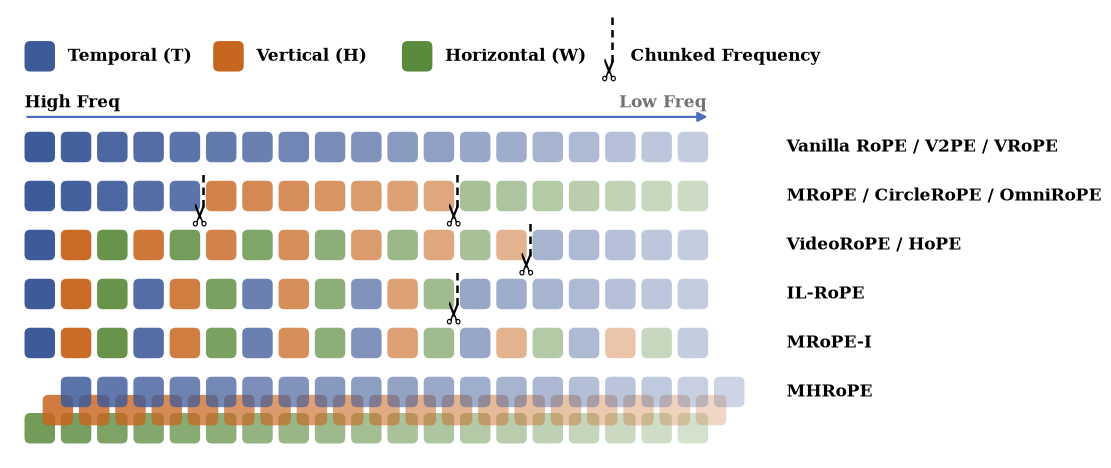

In [7]:
AXIS_COLOR = {T: "#3D5A99", H: "#C8651E", W: "#5A8A3C"}
AXIS_NAME = {T: "Temporal (T)", H: "Vertical (H)", W: "Horizontal (W)"}
SIZE, ROW_PITCH = 0.84, 1.35
LABEL_FONT = dict(fontsize=12.5, fontweight="bold", family="serif", va="center")


def fade(i, n):                      # frequency decays with the pair index -> colour fades left to right
    return 1.0 - 0.7 * i / (n - 1)


def square(ax, x, y, axis, alpha):
    ax.add_patch(FancyBboxPatch((x, y), SIZE, SIZE, boxstyle="round,pad=0,rounding_size=0.16",
                                fc=AXIS_COLOR[axis], ec="none", alpha=alpha))


def draw_row(ax, axes_row, x0, y0, alpha_scale=1.0):
    for i, a in enumerate(axes_row):
        if a:                        # skip NoPE heads
            square(ax, x0 + i, y0, int(a), fade(i, len(axes_row)) * alpha_scale)


def chunk_boundaries(axes_row, min_run=3):
    n, cuts, start = len(axes_row), set(), 0
    for i in range(1, n + 1):
        if i == n or axes_row[i] != axes_row[start]:
            if i - start >= min_run:
                cuts |= {start, i}
            start = i
    return sorted(c for c in cuts if 0 < c < n)


def scissors(ax, x, y0, y1, size=22):
    ax.plot([x, x], [y0 + 0.22, y1], color="black", lw=1.8, ls=(0, (3, 2)))
    ax.text(x, y0, "✂", fontsize=size, ha="center", va="center", rotation=90)


fig3, ax = plt.subplots(figsize=(14, 7))
y_top = 8.6
label_x = N_PAIRS + 2.0
for r, (name, rows) in enumerate(ROWS):
    layers = [np.array(l) for l in dict.fromkeys(map(tuple, rows))]   # distinct rows: 1, or 3 head groups
    k = len(layers)
    y = y_top - r * ROW_PITCH - 0.5 * (k - 1)
    for j, layer in reversed(list(enumerate(layers))):                # W layer first, T layer on top
        off = 0.5 * (k - 1 - j)
        draw_row(ax, layer, off, y + off, alpha_scale=0.85 if k > 1 else 1.0)
        for c in chunk_boundaries(layer):
            scissors(ax, c - (1 - SIZE) / 2, y - 0.1, y + 1.1)
    ax.text(label_x, y + SIZE / 2 + 0.5 * (k - 1), name, **LABEL_FONT)
y_bottom = y

y_arrow = y_top + 1.25
ax.annotate("", xy=(N_PAIRS - 0.1, y_arrow), xytext=(0, y_arrow),
            arrowprops=dict(arrowstyle="-|>", color="#4A6FBF", lw=1.6, mutation_scale=14))
ax.text(0, y_arrow + 0.15, "High Freq", fontsize=12.5, fontweight="bold", family="serif", va="bottom")
ax.text(N_PAIRS - 0.2, y_arrow + 0.15, "Low Freq", fontsize=12.5, fontweight="bold", family="serif",
        va="bottom", ha="right", color="0.45")

y_leg = y_top + 2.5
for x, axis in zip((0, 5.2, 10.4), (T, H, W)):
    square(ax, x, y_leg, axis, 1.0)
    ax.text(x + SIZE + 0.35, y_leg + SIZE / 2, AXIS_NAME[axis], **LABEL_FONT)
scissors(ax, 16.2, y_leg + 0.05, y_leg + 1.6)
ax.text(16.7, y_leg + SIZE / 2, "Chunked Frequency", **LABEL_FONT)

ax.set_xlim(-0.4, label_x + 8.5)
ax.set_ylim(y_bottom - 0.4, y_leg + 1.7)
ax.set_aspect("equal")
ax.axis("off")

OUT3 = REPO_ROOT / "notebooks" / "figure3_frequency_allocation.png"
fig3.savefig(OUT3, dpi=200, bbox_inches="tight")
print("saved", OUT3)
plt.show()

## Notes

* Opened outside the repository (e.g. Google Colab), the first cell clones
  `YongchengYAO/Multimodal-RoPEs` into the working directory and installs missing packages.
* The interactive figure needs a Plotly-capable frontend (VSCode, JupyterLab, Colab). The PDF export keeps
  only the static Figure 1.
* The token counts and grid sizes are estimates read from the published figure; change `SEQUENCE` to
  explore other layouts, the annotations follow the data.
* Panels (a)–(c) and (f) use the repository defaults except `temporal_stride`, which is set to the
  value of the method each panel illustrates (1 for Qwen2-VL MRoPE, 2 for VideoRoPE).
* Figure 3 is drawn from the repo's `apply_transformation` code. One square differs from the paper: the
  repo's VideoRoPE leaves rotary pair 0 on the temporal axis (its interleave offsets start at 1, so W also
  gets one pair fewer than `mrope_section` asks for), whereas the paper starts the H/W alternation at pair 0.